## Models

**Goal**: Prepare dataset for ML modelling and start modelling

**Issues**:
* Encode the data_type and data_subject_type features
* Validate within the train set

In [187]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix, f1_score, precision_score, recall_score, accuracy_score, silhouette_score
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, MultiLabelBinarizer
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, train_test_split, cross_validate
from catboost import CatBoostClassifier
import numpy as np
from kmodes.kmodes import KModes
from sklearn.cluster import KMeans

In [188]:
# CSV file path
DF_HEALTH_PATH = "new-data-security-incident-trends-health-sector.csv"
# Target feature
TARGET_COL = "decision_taken"
# Multilabel columns contain a comma separated list of values and need multi label encoding
MULTILABEL_COLS = ["data_subject_type", "data_type"]
# Categorical columns are single value and need one hot encoding
CATEGORICAL_COLS = ["incident_category", "incident_type", "no_data_subjects_affected", "time_taken_to_report"]
# All feature columns
FEATURE_COLS = MULTILABEL_COLS + CATEGORICAL_COLS

In [189]:
# Load the preprocessed dataset
df = pd.read_csv(DF_HEALTH_PATH)

# Initial check for null values and data types - columns are int64 and object, no nulls
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9250 entries, 0 to 9249
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   year                       9250 non-null   int64 
 1   quarter                    9250 non-null   object
 2   data_subject_type          9250 non-null   object
 3   data_type                  9250 non-null   object
 4   decision_taken             9250 non-null   object
 5   incident_category          9250 non-null   object
 6   incident_type              9250 non-null   object
 7   no_data_subjects_affected  9250 non-null   object
 8   time_taken_to_report       9250 non-null   object
dtypes: int64(1), object(8)
memory usage: 650.5+ KB


In [190]:
# define the train/ test period: train 2021 Q2 - 2024 Q1, test 2024 Q4 - 2025 Q1 & Q2
def is_test_split(row):
    return(row["year"] == 2025)
    
# temp column to check train vs test split
df["is_test"] = df.apply(is_test_split, axis=1)
print(df["is_test"].value_counts())

# split into train and test sets
df_train = df[df["is_test"] == False].reset_index(drop=True)
df_test = df[df["is_test"] == True].reset_index(drop=True)

# drop temp column but keep year and quarter for now to check distribution in train vs test sets
df = df.drop(columns=["is_test"])

# drop year, quarter and is_test columns for modeling
df_train = df_train.drop(columns=["is_test"])
df_test = df_test.drop(columns=["is_test"]) 

# summary of years and quarters in train vs test sets
print("\nTraining set:\n", df_train[["year", "quarter"]].drop_duplicates().sort_values(["year", "quarter"]))
print("\nTest set:\n", df_test[["year", "quarter"]].drop_duplicates().sort_values(["year", "quarter"]))

is_test
False    7312
True     1938
Name: count, dtype: int64

Training set:
       year quarter
0     2021   Qtr 2
603   2021   Qtr 3
1035  2021   Qtr 4
1496  2022   Qtr 1
1917  2022   Qtr 2
2348  2022   Qtr 3
2829  2022   Qtr 4
3269  2023   Qtr 1
3723  2023   Qtr 2
4181  2023   Qtr 3
4682  2023   Qtr 4
5121  2024   Qtr 1
5631  2024   Qtr 2
6165  2024   Qtr 3
6766  2024   Qtr 4

Test set:
       year quarter
0     2025   Qtr 1
533   2025   Qtr 2
1032  2025   Qtr 3
1474  2025   Qtr 4


In [191]:
df_train.info()
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7312 entries, 0 to 7311
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   year                       7312 non-null   int64 
 1   quarter                    7312 non-null   object
 2   data_subject_type          7312 non-null   object
 3   data_type                  7312 non-null   object
 4   decision_taken             7312 non-null   object
 5   incident_category          7312 non-null   object
 6   incident_type              7312 non-null   object
 7   no_data_subjects_affected  7312 non-null   object
 8   time_taken_to_report       7312 non-null   object
dtypes: int64(1), object(8)
memory usage: 514.3+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1938 entries, 0 to 1937
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   year            

In [192]:
# check counts and proportions of target variable (decision taken) in original, train and test sets
for name, subset in [("Original", df), ("Train", df_train), ("Test", df_test)]:
    counts = subset[TARGET_COL].value_counts()
    proportions = subset[TARGET_COL].value_counts(normalize=True).mul(100).round(1)
    summary = pd.DataFrame({f"{name} Count": counts, f"{name} Proportion (%)": proportions})
    print(f"\n{name} Set Decision Taken Summary:\n{summary}")


Original Set Decision Taken Summary:
                       Original Count  Original Proportion (%)
decision_taken                                                
Informal Action Taken            7670                     82.9
No Further Action                 982                     10.6
Investigation Pursued             598                      6.5

Train Set Decision Taken Summary:
                       Train Count  Train Proportion (%)
decision_taken                                          
Informal Action Taken         5834                  79.8
No Further Action              910                  12.4
Investigation Pursued          568                   7.8

Test Set Decision Taken Summary:
                       Test Count  Test Proportion (%)
decision_taken                                        
Informal Action Taken        1836                 94.7
No Further Action              72                  3.7
Investigation Pursued          30                  1.5


In [193]:
# Encode multilabel columns using MultiLabelBinarizer
mlb_encoders = {}
mlb_train_dfs = []
mlb_test_dfs = []

for col in MULTILABEL_COLS:
    # split each cell of ", " to get a list of values for each row
    train_lists = df_train[col].str.split(", ")
    test_lists = df_test[col].str.split(", ")
    
    mlb = MultiLabelBinarizer()
    mlb.fit(train_lists) # fit on training data only to avoid data leakage
    mlb_encoders[col] = mlb # store encoder for later use on test set
    
    # transform both sets 
    train_encoded = pd.DataFrame(
        mlb.transform(train_lists),
        columns=[f"{col}__{cls}" for cls in mlb.classes_],
        index=df_train.index
    )
    
    test_encoded = pd.DataFrame(
        mlb.transform(test_lists),
        columns=[f"{col}__{cls}" for cls in mlb.classes_],
        index=df_test.index
    )
    
    # store the encoded dataframes for later concatenation
    mlb_train_dfs.append(train_encoded)
    mlb_test_dfs.append(test_encoded)
    
    # check how many unique labels were found and what they are
    print(f"{col}: {len(mlb.classes_)} unique labels found")
    print(f"Labels: {list(mlb.classes_)}\n")
    
    # checks to see how encoding looks
    #print(f"Encoded sample of {col} in training set:\n{train_encoded.head()}\n")
    #print(f"Encoded sample of {col} in test set:\n{test_encoded.head()}\n")
    

data_subject_type: 9 unique labels found
Labels: ['Children', 'Customers or prospective customers', 'Employees', 'Patients', 'Students', 'Subscribers', 'Unknown', 'Users', 'Vulnerable adults']

data_type: 16 unique labels found
Labels: ['Basic personal identifiers', 'Criminal convictions or offences', 'Data revealing racial or ethnic origin', 'Economic and financial data', 'Gender Reassignment Data', 'Genetic or biometric data', 'Health data', 'Identification data', 'Location data', 'Official documents', 'Political opinions', 'Religious or philosophical beliefs', 'Sex life data', 'Sexual orientation data', 'Trade union membership', 'Unknown']



In [194]:
# Encode the other categorical columns using OneHotEncoder
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
ohe.fit(df_train[CATEGORICAL_COLS]) # fit on training data only to avoid data leakage

ohe_train = pd.DataFrame(
    ohe.transform(df_train[CATEGORICAL_COLS]),
    columns=ohe.get_feature_names_out(CATEGORICAL_COLS),
    index=df_train.index
)

ohe_test = pd.DataFrame(
    ohe.transform(df_test[CATEGORICAL_COLS]),
    columns=ohe.get_feature_names_out(CATEGORICAL_COLS),
    index=df_test.index
)

# check how many unique values were found for each column, 34 total
for col in CATEGORICAL_COLS:
    unique_cats = df_train[col].nunique()
    print(f"{col}: {unique_cats} unique values found")

incident_category: 2 unique values found
incident_type: 21 unique values found
no_data_subjects_affected: 7 unique values found
time_taken_to_report: 4 unique values found


In [195]:
# Concatenate the MLB and OHE encoded features
X_train = pd.concat(mlb_train_dfs + [ohe_train], axis=1)
X_test = pd.concat(mlb_test_dfs + [ohe_test], axis=1)

y_train = df_train[TARGET_COL]
y_test = df_test[TARGET_COL]

print("Encoded feature shapes:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Target shapes:")
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

# confirm no nulls in encoded features
#print("\nNull values in X_train:\n", X_train.isnull().sum())
#print("\nNull values in X_test:\n", X_test.isnull().sum())

Encoded feature shapes:
X_train: (7312, 59)
X_test: (1938, 59)
Target shapes:
y_train: (7312,)
y_test: (1938,)


In [196]:
# function for evaluation metrics 
CLASS_LABELS = sorted(df[TARGET_COL].unique()) # get sorted list of unique target labels for consistent labelling

def evaluate_model(model_name, y_true, y_pred):
    # model name, ground truth, predicted values
    
    print(f"{model_name} Evaluation")
    
    # Per class breakdown of precision, recall and f1 score
    print("Classification Report:")
    print(classification_report(y_true, y_pred, labels=CLASS_LABELS, zero_division=0))
    
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
    
    # display confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=CLASS_LABELS)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_LABELS)
    disp.plot(cmap=plt.cm.plasma, ax=ax, colorbar=False)
    ax.set_title(f"{model_name} Confusion Matrix", fontsize=14, fontweight='bold', pad=12)
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    plt.show()
    
    # confusion matrix table
    cm_df = pd.DataFrame(cm, index=CLASS_LABELS, columns=CLASS_LABELS)
    print("Confusion Matrix:\n", cm_df)
    
    # return metrics to potentially store them for comparing models later on
    return {
        "model": model_name,
        "accuracy": round(acc, 4),
        "macro_f1": round(macro_f1, 4),
        "precision": round(precision, 4),
        "recall": round(recall, 4)
    }

In [197]:
# Setup for time series cross validation - NEED TO DO TUNING LATER
N_SPLITS = 5
RANDOM_STATE = 42
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

rf_cv = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# cross validate returns per fold scores for each metric
rf_cv_results = cross_validate(
    rf_cv,
    X_train,
    y_train,
    cv=tscv,
    scoring={
        "accuracy": "accuracy",
        "macro_f1": "f1_macro",
        "precision": "precision_macro",
        "recall": "recall_macro"
    },
    error_score="raise"
)

# Summarise CV results across folds - RF, CV SCORES, TSS, 5 Folds
rf_cv_summary = pd.DataFrame({
    metric.replace("test_", ""): scores
    for metric, scores in rf_cv_results.items()
    if metric.startswith("test_")
})

# Add mean and std rows to summary
rf_cv_summary.index = [f"Fold {i+1}" for i in range(N_SPLITS)]
rf_cv_summary.loc["Mean"] = rf_cv_summary.mean()
rf_cv_summary.loc["Std"] = rf_cv_summary.std()
print(rf_cv_summary.round(4).to_string())

        accuracy  macro_f1  precision  recall
Fold 1    0.7882    0.4629     0.5006  0.4521
Fold 2    0.7233    0.4695     0.4763  0.4730
Fold 3    0.7167    0.4406     0.4613  0.4298
Fold 4    0.7512    0.5040     0.4854  0.5411
Fold 5    0.7028    0.4237     0.4257  0.4581
Mean      0.7365    0.4602     0.4698  0.4708
Std       0.0303    0.0273     0.0255  0.0378


In [198]:
# Train final model on full training set
rf_final = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_final.fit(X_train, y_train)
print("Random Forest trained on full training set:")
print(f"Features: {X_train.shape[1]}") #59
print(f"Rows: {X_train.shape[0]}") #6766


Random Forest trained on full training set:
Features: 59
Rows: 7312


Random Forest Evaluation
Classification Report:
                       precision    recall  f1-score   support

Informal Action Taken       0.96      0.83      0.89      1836
Investigation Pursued       0.02      0.10      0.03        30
    No Further Action       0.16      0.33      0.21        72

             accuracy                           0.80      1938
            macro avg       0.38      0.42      0.38      1938
         weighted avg       0.92      0.80      0.86      1938



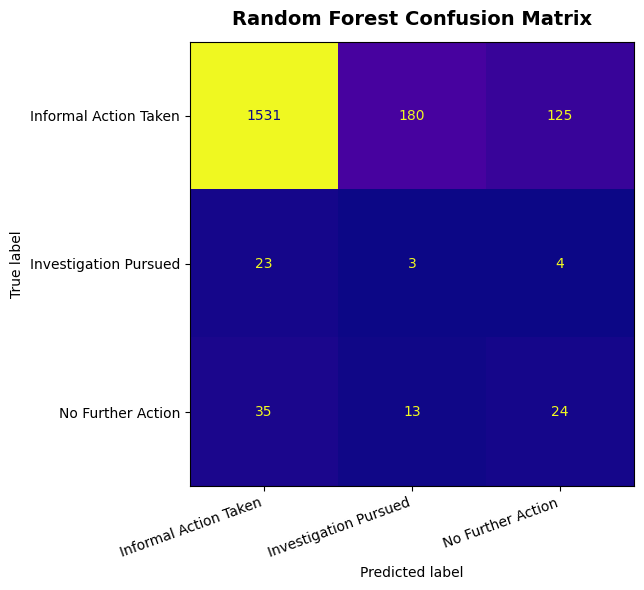

Confusion Matrix:
                        Informal Action Taken  Investigation Pursued  \
Informal Action Taken                   1531                    180   
Investigation Pursued                     23                      3   
No Further Action                         35                     13   

                       No Further Action  
Informal Action Taken                125  
Investigation Pursued                  4  
No Further Action                     24  


In [199]:
# Evaluate on test set
y_pred_rf = rf_final.predict(X_test)
rf_metrics = evaluate_model("Random Forest", y_test, y_pred_rf)

In [200]:
# Helper function to get original feature name from encoded column name

# mlb columns: original_col__label
# ohe columns: original_col_label
def get_original_feature(col_name):
    if "__" in col_name:
        return col_name.split("__")[0] # return mlb features
    for col in CATEGORICAL_COLS:
        if col_name.startswith(col):
            return col # for ohe features, get original column name
    return col_name # for mlb features, return as is

Feature Importance Summary (grouped by original feature):
         original_feature  importance
            incident_type      0.2773
        data_subject_type      0.1821
                data_type      0.1773
no_data_subjects_affected      0.1430
     time_taken_to_report      0.1242
        incident_category      0.0962


C:\Users\elsad\AppData\Local\Temp\ipykernel_17392\2157489678.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(rf_feature_summary["original_feature"], rotation=45, ha='right')


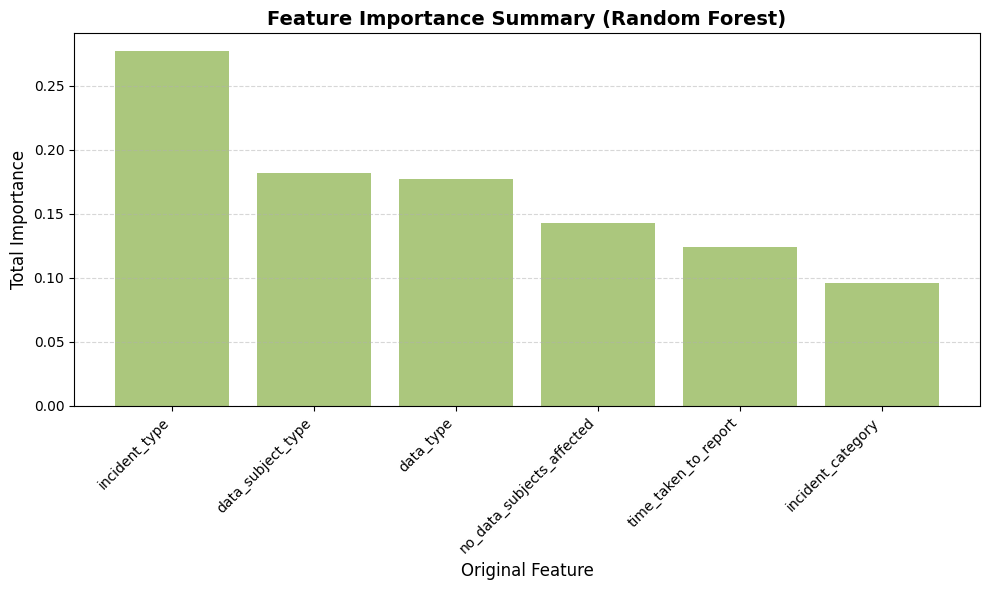

In [201]:
# Extract feature importance to see what columns the model is learning from
rf_importances_df = pd.DataFrame({
    "feature": X_train.columns, 
    "importance": rf_final.feature_importances_
}).sort_values(by="importance", ascending=False)

# add original feature column to importances df by applying the function to the feature names
rf_importances_df["original_feature"] = rf_importances_df["feature"].apply(get_original_feature)

# group by original feature and sum importance to see which features are important
rf_feature_summary = (
    rf_importances_df
    .groupby("original_feature")["importance"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# table of feature importance summary
print("Feature Importance Summary (grouped by original feature):")
print(rf_feature_summary.round(4).to_string(index=False))

# bar chart of feature importance summary
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(rf_feature_summary["original_feature"], rf_feature_summary["importance"], color="#abc77d")
ax.set_title("Feature Importance Summary (Random Forest)", fontsize=14, fontweight='bold')
ax.set_xlabel("Original Feature", fontsize=12)
ax.set_ylabel("Total Importance", fontsize=12)
ax.set_xticklabels(rf_feature_summary["original_feature"], rotation=45, ha='right')
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [202]:
# tests for random forest 

# Test 1: predictions cover the full test set
assert len(y_pred_rf) == len(y_test), "Length of predictions does not match length of test labels"
print("1. Prediction count matches test label count")
print(f"\t{len(y_pred_rf)} predictions, {len(y_test)} test labels")

# Test 2: all predicted classes are valid known labels
assert set(y_pred_rf).issubset(set(CLASS_LABELS)), f"Predicted classes contain unknown labels: {set(y_pred_rf) - set(CLASS_LABELS)}"
print("2. All predicted classes are valid known labels")
print(f"\tSet of predicted classes: {set(y_pred_rf)}")

# Test 3: feature importances sum to approximately 1
assert abs(rf_importances_df["importance"].sum() - 1.0) < 1e-6, "Feature importances do not sum to approximately 1"
print("3. Feature importances sum to approximately 1")
print(f"\tSum of feature importances: {rf_importances_df['importance'].sum():.6f}")

# Test 4: model was trained on correct number of features
assert rf_final.n_features_in_ == X_train.shape[1], f"Model was trained on {rf_final.n_features_in_} features but expected {X_train.shape[1]}"
print("4. Model was trained on the correct number of features")
print(f"\t{rf_final.n_features_in_} features in model, {X_train.shape[1]} features in training data")

# Test 5: CV macro F1 mean us above a naive baseline 
mean_cv_f1 = rf_cv_results["test_macro_f1"].mean()
assert mean_cv_f1 > 0.2, f"Mean CV macro F1 score {mean_cv_f1:.4f} is not above the naive baseline of 0.2"
print(f"5. Mean CV macro F1 score {mean_cv_f1:.4f} is above the naive baseline of 0.2")
print(f"\tCV macro F1 scores across folds: {rf_cv_results['test_macro_f1']}")

# Test 6: no data leakage, test set rows aren't in the training set
train_periods = set(zip(df_train["year"], df_train["quarter"]))
test_periods = set(zip(df_test["year"], df_test["quarter"]))
assert train_periods.isdisjoint(test_periods), f"Data leakage detected: overlapping periods in train and test sets: {train_periods.intersection(test_periods)}"
print("6. No data leakage detected between train and test sets")
print(f"\t{sorted(train_periods)} training periods, {sorted(test_periods)} test periods")


1. Prediction count matches test label count
	1938 predictions, 1938 test labels
2. All predicted classes are valid known labels
	Set of predicted classes: {'No Further Action', 'Investigation Pursued', 'Informal Action Taken'}
3. Feature importances sum to approximately 1
	Sum of feature importances: 1.000000
4. Model was trained on the correct number of features
	59 features in model, 59 features in training data
5. Mean CV macro F1 score 0.4602 is above the naive baseline of 0.2
	CV macro F1 scores across folds: [0.46292037 0.46951355 0.44064443 0.5039868  0.42372251]
6. No data leakage detected between train and test sets
	[(2021, 'Qtr 2'), (2021, 'Qtr 3'), (2021, 'Qtr 4'), (2022, 'Qtr 1'), (2022, 'Qtr 2'), (2022, 'Qtr 3'), (2022, 'Qtr 4'), (2023, 'Qtr 1'), (2023, 'Qtr 2'), (2023, 'Qtr 3'), (2023, 'Qtr 4'), (2024, 'Qtr 1'), (2024, 'Qtr 2'), (2024, 'Qtr 3'), (2024, 'Qtr 4')] training periods, [(2025, 'Qtr 1'), (2025, 'Qtr 2'), (2025, 'Qtr 3'), (2025, 'Qtr 4')] test periods


In [203]:
# CV CatBoost on training set - NEED TO DO TUNING LATER
cb_cv = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    auto_class_weights="Balanced",
    random_state=RANDOM_STATE,
    verbose=0
)

cb_cv_results = cross_validate(
    cb_cv,
    X_train,
    y_train,
    cv=tscv,
    scoring={
        "accuracy": "accuracy",
        "macro_f1": "f1_macro",
        "precision": "precision_macro",
        "recall": "recall_macro"
    },
    return_train_score=False,
    error_score="raise"
)

# Summaries CV results across folds - CatBoost, CV SCORES, TSS, 5 Folds
print("\nCatBoost CV Results:")
cb_cv_summary = pd.DataFrame({
    metric.replace("test_", ""): scores
    for metric, scores in cb_cv_results.items()
    if metric.startswith("test_")
})
cb_cv_summary.index = [f"Fold {i+1}" for i in range(N_SPLITS)]
cb_cv_summary.loc["Mean"] = cb_cv_summary.mean() 
cb_cv_summary.loc["Std"] = cb_cv_summary.std()
print(cb_cv_summary.round(4).to_string())


CatBoost CV Results:
        accuracy  macro_f1  precision  recall
Fold 1    0.7291    0.4668     0.4988  0.5019
Fold 2    0.6856    0.4927     0.5126  0.5624
Fold 3    0.6979    0.4841     0.4797  0.4936
Fold 4    0.7291    0.5535     0.5183  0.6752
Fold 5    0.6995    0.5066     0.5152  0.6253
Mean      0.7082    0.5007     0.5049  0.5717
Std       0.0177    0.0294     0.0143  0.0702


In [204]:
# Train on full training set
cb_final = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    auto_class_weights="Balanced",
    random_state=RANDOM_STATE,
    verbose=0
)
cb_final.fit(X_train, y_train)
print("CatBoost trained on full training set:")
print(f"Features: {X_train.shape[1]}") #59
print(f"Rows: {X_train.shape[0]}") #6766

CatBoost trained on full training set:
Features: 59
Rows: 7312


CatBoost Evaluation
Classification Report:
                       precision    recall  f1-score   support

Informal Action Taken       0.97      0.75      0.85      1836
Investigation Pursued       0.03      0.30      0.05        30
    No Further Action       0.17      0.51      0.26        72

             accuracy                           0.73      1938
            macro avg       0.39      0.52      0.39      1938
         weighted avg       0.93      0.73      0.81      1938



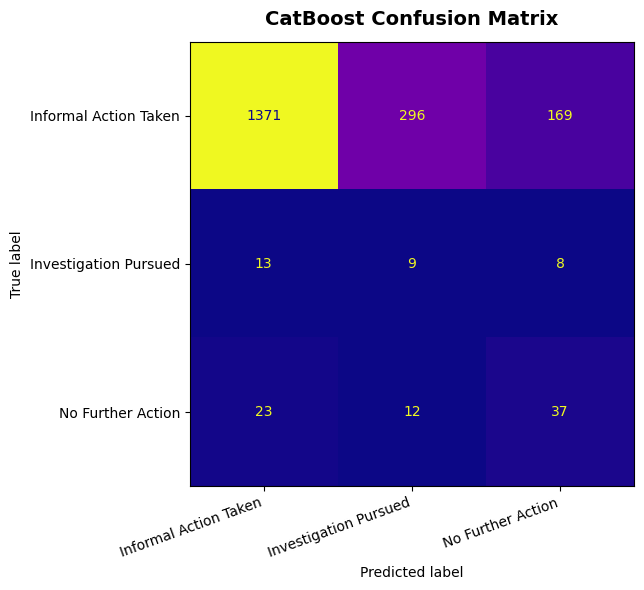

Confusion Matrix:
                        Informal Action Taken  Investigation Pursued  \
Informal Action Taken                   1371                    296   
Investigation Pursued                     13                      9   
No Further Action                         23                     12   

                       No Further Action  
Informal Action Taken                169  
Investigation Pursued                  8  
No Further Action                     37  


In [205]:
# Evaluate CatBoost on test set
y_pred_cb = cb_final.predict(X_test).flatten()
cb_metrics = evaluate_model("CatBoost", y_test, y_pred_cb)

Feature Importance Summary (grouped by original feature):
         original_feature  importance
            incident_type     28.6770
        incident_category     17.2258
no_data_subjects_affected     14.4497
                data_type     13.8837
        data_subject_type     13.7599
     time_taken_to_report     12.0039


C:\Users\elsad\AppData\Local\Temp\ipykernel_17392\3831512288.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cb_feature_summary["original_feature"], rotation=45, ha='right')


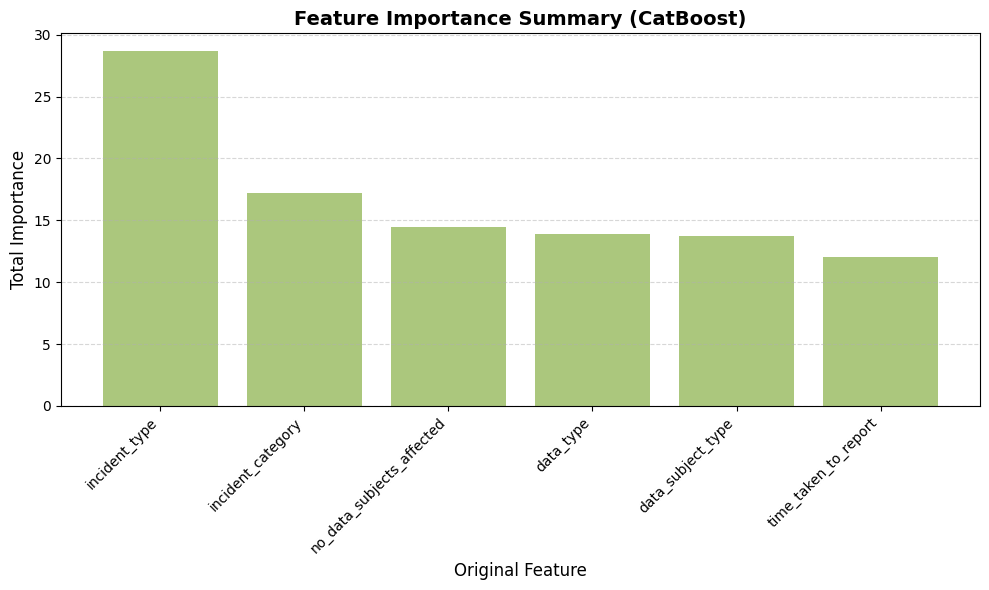

In [206]:
# CatBoost feature importance 
# Extract feature importance to see what columns the model is learning from
cb_importances_df = pd.DataFrame({
    "feature": X_train.columns, 
    "importance": cb_final.feature_importances_
}).sort_values(by="importance", ascending=False)

# add original feature column to importances df by applying the function to the feature names
cb_importances_df["original_feature"] = cb_importances_df["feature"].apply(get_original_feature)

# group by original feature and sum importance to see which features are important
cb_feature_summary = (
    cb_importances_df
    .groupby("original_feature")["importance"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# table of feature importance summary
print("Feature Importance Summary (grouped by original feature):")
print(cb_feature_summary.round(4).to_string(index=False))

# bar chart of feature importance summary
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(cb_feature_summary["original_feature"], cb_feature_summary["importance"], color="#abc77d")
ax.set_title("Feature Importance Summary (CatBoost)", fontsize=14, fontweight='bold')
ax.set_xlabel("Original Feature", fontsize=12)
ax.set_ylabel("Total Importance", fontsize=12)
ax.set_xticklabels(cb_feature_summary["original_feature"], rotation=45, ha='right')
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [207]:
# Tests for CatBoost

# Test 1: predictions cover the full test set
assert len(y_pred_cb) == len(y_test), "Length of predictions does not match length of test labels"
print("1. Prediction count matches test label count")
print(f"\t{len(y_pred_cb)} predictions, {len(y_test)} test labels")

# Test 2: all predicted classes are valid known labels
assert set(y_pred_cb).issubset(set(CLASS_LABELS)), f"Predicted classes contain unknown labels: {set(y_pred_cb) - set(CLASS_LABELS)}"
print("2. All predicted classes are valid known labels")
print(f"\tSet of predicted classes: {set(y_pred_cb)}")

# Test 3: feature importances sum to approximately 1
assert abs(cb_importances_df["importance"].sum() - 100.0) < 1e-3, "Feature importances do not sum to approximately 100"
print("3. Feature importances sum to approximately 100")
print(f"\tSum of feature importances: {cb_importances_df['importance'].sum():.6f}")

# Test 4: model was trained on correct number of features
assert cb_final.n_features_in_ == X_train.shape[1], f"Model was trained on {cb_final.n_features_in_} features but expected {X_train.shape[1]}"
print("4. Model was trained on the correct number of features")
print(f"\t{cb_final.n_features_in_} features in model, {X_train.shape[1]} features in training data")

# Test 5: CV macro F1 mean us above a naive baseline 
mean_cv_f1 = cb_cv_results["test_macro_f1"].mean()
assert mean_cv_f1 > 0.2, f"Mean CV macro F1 score {mean_cv_f1:.4f} is not above the naive baseline of 0.2"
print(f"5. Mean CV macro F1 score {mean_cv_f1:.4f} is above the naive baseline of 0.2")
print(f"\tCV macro F1 scores across folds: {cb_cv_results['test_macro_f1']}")

# Test 6: no data leakage, test set rows aren't in the training set
train_periods = set(zip(df_train["year"], df_train["quarter"]))
test_periods = set(zip(df_test["year"], df_test["quarter"]))
assert train_periods.isdisjoint(test_periods), f"Data leakage detected: overlapping periods in train and test sets: {train_periods.intersection(test_periods)}"
print("6. No data leakage detected between train and test sets")
print(f"\t{sorted(train_periods)} training periods, {sorted(test_periods)} test periods")

1. Prediction count matches test label count
	1938 predictions, 1938 test labels
2. All predicted classes are valid known labels
	Set of predicted classes: {'No Further Action', 'Investigation Pursued', 'Informal Action Taken'}
3. Feature importances sum to approximately 100
	Sum of feature importances: 100.000000
4. Model was trained on the correct number of features
	59 features in model, 59 features in training data
5. Mean CV macro F1 score 0.5007 is above the naive baseline of 0.2
	CV macro F1 scores across folds: [0.46677045 0.4927353  0.48414209 0.55352705 0.50655759]
6. No data leakage detected between train and test sets
	[(2021, 'Qtr 2'), (2021, 'Qtr 3'), (2021, 'Qtr 4'), (2022, 'Qtr 1'), (2022, 'Qtr 2'), (2022, 'Qtr 3'), (2022, 'Qtr 4'), (2023, 'Qtr 1'), (2023, 'Qtr 2'), (2023, 'Qtr 3'), (2023, 'Qtr 4'), (2024, 'Qtr 1'), (2024, 'Qtr 2'), (2024, 'Qtr 3'), (2024, 'Qtr 4')] training periods, [(2025, 'Qtr 1'), (2025, 'Qtr 2'), (2025, 'Qtr 3'), (2025, 'Qtr 4')] test periods


In [208]:
# Collecting all model metrics for comparison 
comparison_df = pd.DataFrame([rf_metrics, cb_metrics]).set_index("model")
print(f"\nModel Comparison:\n {comparison_df.round(4).to_string()}")   

cv_comparison_df = pd.DataFrame({
    "Random Forest": {
        "CV Accuracy Mean" : rf_cv_results["test_accuracy"].mean(),
        "CV Macro F1 Mean" : rf_cv_results["test_macro_f1"].mean(),
        "CV Precision Mean": rf_cv_results["test_precision"].mean(),
        "CV Recall Mean"   : rf_cv_results["test_recall"].mean(),
        "CV Macro F1 Std"  : rf_cv_results["test_macro_f1"].std(),
    },
    "CatBoost": {
        "CV Accuracy Mean" : cb_cv_results["test_accuracy"].mean(),
        "CV Macro F1 Mean" : cb_cv_results["test_macro_f1"].mean(),
        "CV Precision Mean": cb_cv_results["test_precision"].mean(),
        "CV Recall Mean"   : cb_cv_results["test_recall"].mean(),
        "CV Macro F1 Std"  : cb_cv_results["test_macro_f1"].std(),
    }
}).round(4)

print(f"\nCross Validation Comparison:")
print(cv_comparison_df.to_string())



Model Comparison:
                accuracy  macro_f1  precision  recall
model                                               
Random Forest    0.8039    0.3780     0.3786  0.4224
CatBoost         0.7312    0.3854     0.3919  0.5202

Cross Validation Comparison:
                   Random Forest  CatBoost
CV Accuracy Mean          0.7365    0.7082
CV Macro F1 Mean          0.4602    0.5007
CV Precision Mean         0.4698    0.5049
CV Recall Mean            0.4708    0.5717
CV Macro F1 Std           0.0273    0.0294


Per-class F1 Scores:
                       Random Forest  CatBoost
Informal Action Taken         0.8940    0.8455
Investigation Pursued         0.0265    0.0519
No Further Action             0.2133    0.2587


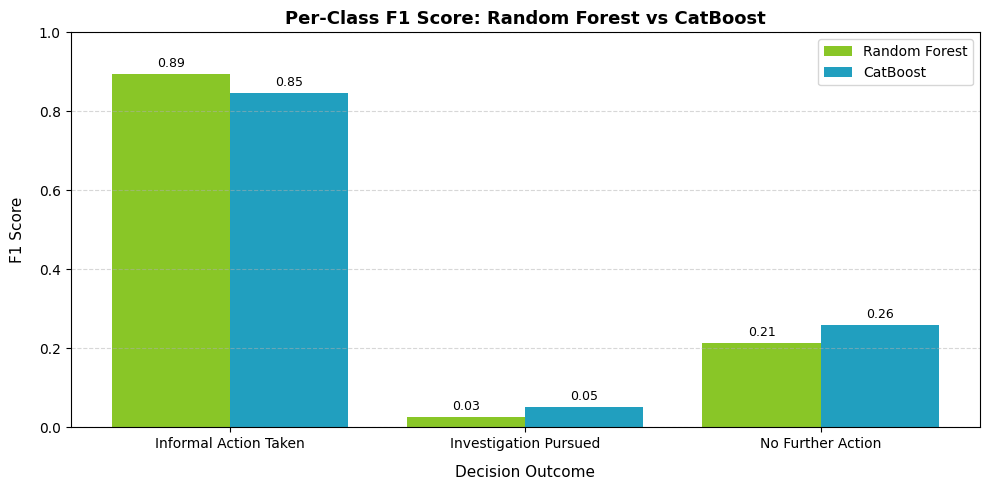

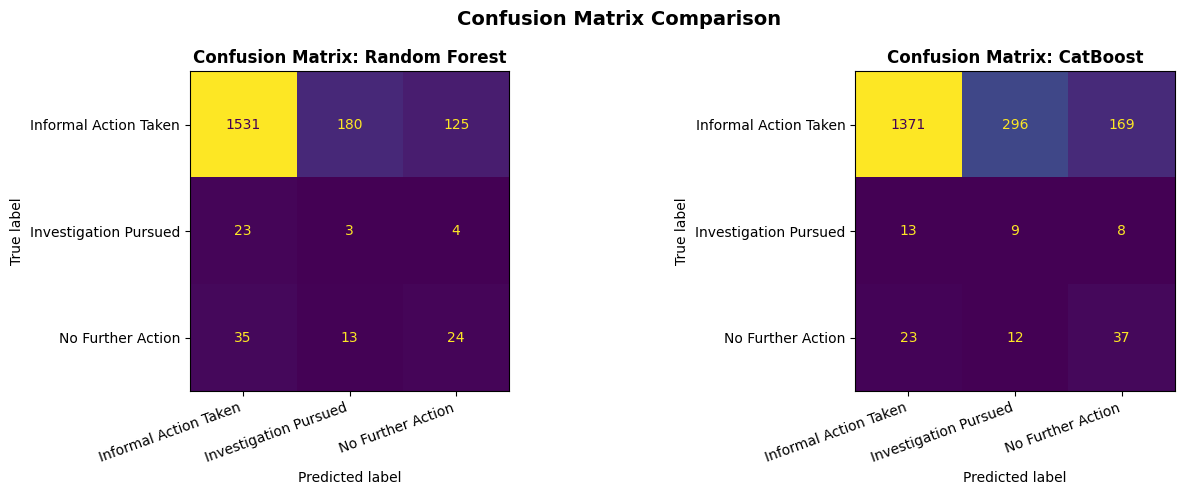


Random Forest Confusion Matrix:
                       Informal Action Taken  Investigation Pursued  No Further Action
Informal Action Taken                   1531                    180                125
Investigation Pursued                     23                      3                  4
No Further Action                         35                     13                 24

CatBoost Confusion Matrix:
                       Informal Action Taken  Investigation Pursued  No Further Action
Informal Action Taken                   1371                    296                169
Investigation Pursued                     13                      9                  8
No Further Action                         23                     12                 37


In [209]:
# Per-class F1 scores
rf_f1_per_class = f1_score(y_test, y_pred_rf, labels=CLASS_LABELS, average=None, zero_division=0)
cb_f1_per_class = f1_score(y_test, y_pred_cb, labels=CLASS_LABELS, average=None, zero_division=0)

f1_comparison = pd.DataFrame({
    "Random Forest": rf_f1_per_class,
    "CatBoost"     : cb_f1_per_class,
}, index=CLASS_LABELS)

print(f"Per-class F1 Scores:\n{f1_comparison.round(4).to_string()}")

# Per class F1 score bar chart comparison
x = np.arange(len(CLASS_LABELS))
width = 0.4
fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, rf_f1_per_class, width, label="Random Forest", color="#89c627")
bars2 = ax.bar(x + width/2, cb_f1_per_class, width, label="CatBoost", color="#219fbf")

ax.set_title("Per-Class F1 Score: Random Forest vs CatBoost", fontsize=13, fontweight="bold")
ax.set_xlabel("Decision Outcome", fontsize=11, labelpad=10)
ax.set_ylabel("F1 Score", fontsize=11, labelpad=10)
ax.set_xticks(x)
ax.set_xticklabels(CLASS_LABELS)
ax.set_ylim(0, 1.0)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

# Side by side confusion matrix comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, y_pred, title in zip(axes, [y_pred_rf, y_pred_cb], ["Random Forest", "CatBoost"]):
    cm = confusion_matrix(y_test, y_pred, labels=CLASS_LABELS)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_LABELS)
    disp.plot(cmap="viridis", ax=ax, colorbar=False)
    ax.set_title(f"Confusion Matrix: {title}", fontsize=12, fontweight="bold")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")

plt.suptitle("Confusion Matrix Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# confusion matrix values in table format for easier comparison
for y_pred, title in zip([y_pred_rf, y_pred_cb], ["Random Forest", "CatBoost"]):
    cm = confusion_matrix(y_test, y_pred, labels=CLASS_LABELS)
    cm_df = pd.DataFrame(cm, index=CLASS_LABELS, columns=CLASS_LABELS)
    print(f"\n{title} Confusion Matrix:\n{cm_df.round(4).to_string()}")



Feature Importance Comparison (normalised to 0-1):
                           Random Forest  CatBoost
group                                             
incident_type                     0.2773    0.2868
data_subject_type                 0.1821    0.1376
data_type                         0.1773    0.1388
no_data_subjects_affected         0.1430    0.1445
time_taken_to_report              0.1242    0.1200
incident_category                 0.0962    0.1723


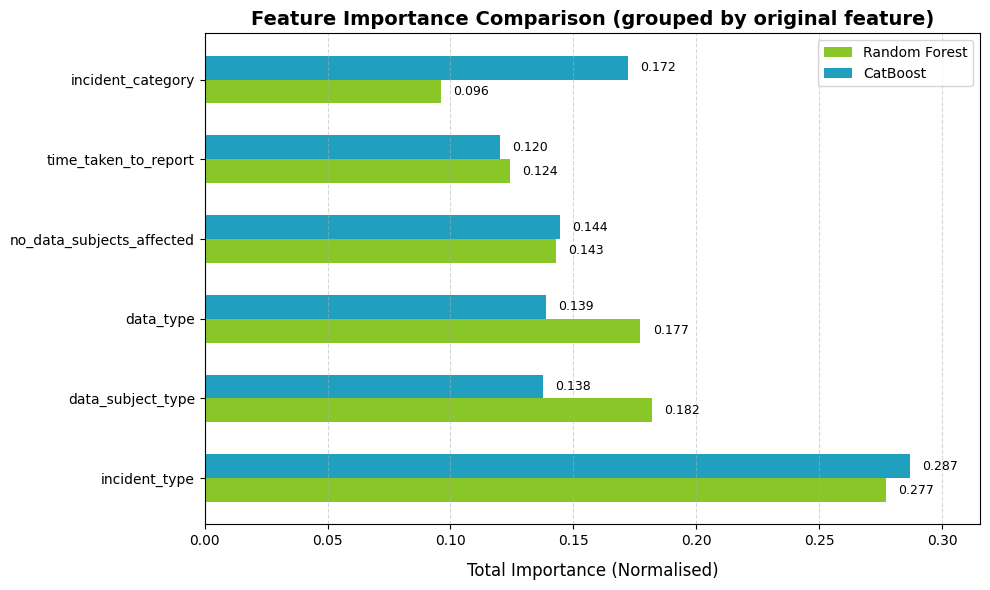

In [210]:
# RF importance grouped
rf_importance = pd.DataFrame({
    "feature"   : X_train.columns,
    "importance": rf_final.feature_importances_
})
rf_importance["group"] = rf_importance["feature"].apply(get_original_feature)
rf_grouped = rf_importance.groupby("group")["importance"].sum().sort_values(ascending=False)

# CatBoost importance grouped (corrected)
cb_importance = pd.DataFrame({
    "feature"   : X_train.columns,
    "importance": cb_final.get_feature_importance()
})
cb_importance["group"] = cb_importance["feature"].apply(get_original_feature)

# Normalise CatBoost to 0-1 scale to match RF for fair visual comparison
cb_grouped = cb_importance.groupby("group")["importance"].sum()
cb_grouped = (cb_grouped / cb_grouped.sum()).sort_values(ascending=False)

# Align both on the same feature order (RF order)
all_features = rf_grouped.index.tolist()
imp_comparison = pd.DataFrame({
    "Random Forest": rf_grouped.reindex(all_features),
    "CatBoost": cb_grouped.reindex(all_features),
}).fillna(0)

print("Feature Importance Comparison (normalised to 0-1):")
print(imp_comparison.round(4).to_string())

# Grouped horizontal bar chart
x = np.arange(len(all_features))
width = 0.3
fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.barh(x - width/2, imp_comparison["Random Forest"], height=width, label="Random Forest", color="#89c627")
bars2 = ax.barh(x + width/2, imp_comparison["CatBoost"], height=width, label="CatBoost", color="#219fbf")

ax.set_title("Feature Importance Comparison (grouped by original feature)", fontsize=14, fontweight="bold")
ax.set_xlabel("Total Importance (Normalised)", fontsize=12, labelpad=10)
ax.set_xlim(0, max(imp_comparison.max()) * 1.1)
ax.set_yticks(x)
ax.set_yticklabels(all_features)
ax.legend()
ax.grid(axis="x", linestyle="--", alpha=0.5)

for bar in bars1:
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():.3f}", va="center", fontsize=9)
for bar in bars2:
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():.3f}", va="center", fontsize=9)  
plt.tight_layout()
plt.show()

In [211]:
# Cluster feature matrix

X_cluster = pd.concat([X_train, X_test], axis=0).reset_index(drop=True)
y_cluster = pd.concat([y_train, y_test], axis=0).reset_index(drop=True)

print(f"Cluster matrix shape: {X_cluster.shape}")
print(f"Cluster target shape: {y_cluster.shape}")
print(f"Class distribution in cluster data:\n{y_cluster.value_counts()}")

Cluster matrix shape: (9250, 59)
Cluster target shape: (9250,)
Class distribution in cluster data:
decision_taken
Informal Action Taken    7670
No Further Action         982
Investigation Pursued     598
Name: count, dtype: int64


In [212]:
# Kmodes, elbow and silhouette analysis to determine optimal number of clusters

kmodes_costs = []
kmodes_silhouette = []

for k in range(2, 11):
    km = KModes(n_clusters=k, init="Huang", n_init=5, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_cluster)
    kmodes_costs.append(km.cost_)
    
    sil = silhouette_score(X_cluster, labels, metric="hamming")
    kmodes_silhouette.append(sil)
    print(f"K={k}: Cost={km.cost_}, Silhouette={sil:.4f}")

K=2: Cost=39716.0, Silhouette=0.2932
K=3: Cost=37213.0, Silhouette=0.1869
K=4: Cost=35405.0, Silhouette=0.1490
K=5: Cost=33695.0, Silhouette=0.1755
K=6: Cost=33803.0, Silhouette=0.1060
K=7: Cost=31398.0, Silhouette=0.0830
K=8: Cost=28881.0, Silhouette=0.1508
K=9: Cost=28759.0, Silhouette=0.2227
K=10: Cost=27595.0, Silhouette=0.1650


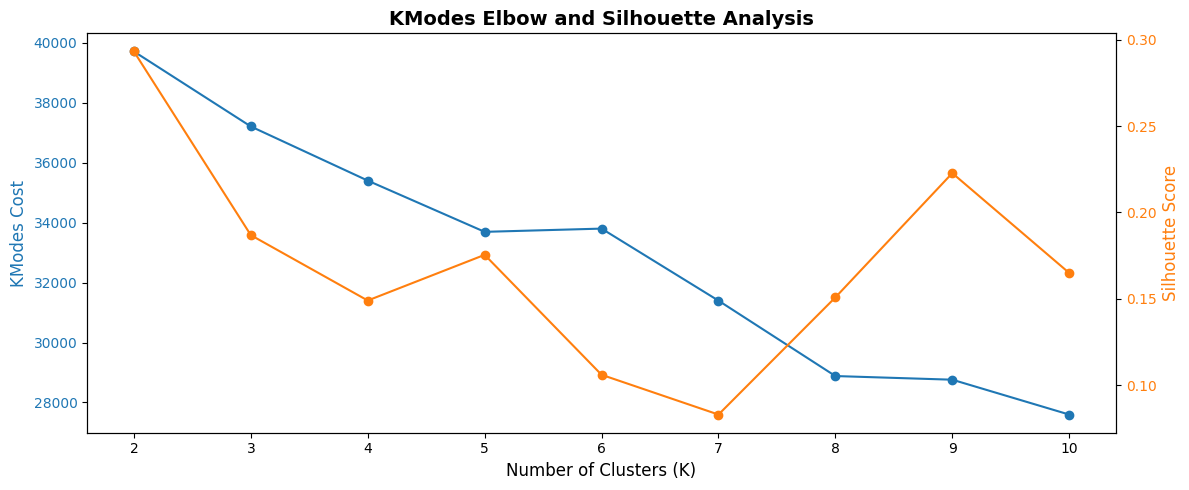


KModes Clustering Summary:
  K    Cost  Silhouette
 2 39716.0      0.2932
 3 37213.0      0.1869
 4 35405.0      0.1490
 5 33695.0      0.1755
 6 33803.0      0.1060
 7 31398.0      0.0830
 8 28881.0      0.1508
 9 28759.0      0.2227
10 27595.0      0.1650


In [213]:
# Elbow & Silhouette plots
fig, ax1 = plt.subplots(figsize=(12, 5))
color = "tab:blue"
ax1.set_xlabel("Number of Clusters (K)", fontsize=12)
ax1.set_ylabel("KModes Cost", color=color, fontsize=12)
ax1.plot(range(2, 11), kmodes_costs, marker="o", color=color)
ax1.tick_params(axis="y", labelcolor=color)
ax2 = ax1.twinx()
color = "tab:orange"
ax2.set_ylabel("Silhouette Score", color=color, fontsize=12)
ax2.plot(range(2, 11), kmodes_silhouette, marker="o", color=color)
ax2.tick_params(axis="y", labelcolor=color)
plt.title("KModes Elbow and Silhouette Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# table of costs and silhouette scores for each K
kmodes_summary = pd.DataFrame({
    "K": range(2, 11),
    "Cost": kmodes_costs,
    "Silhouette": kmodes_silhouette
})
print("\nKModes Clustering Summary:\n", kmodes_summary.round(4).to_string(index=False))

In [214]:
# KMeans clustering
kmeans_inertia = []
kmeans_silhouette = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_cluster)
    kmeans_inertia.append(km.inertia_)
    
    sil = silhouette_score(X_cluster, labels, metric="euclidean")
    kmeans_silhouette.append(sil)
    print(f"K={k}: Inertia={km.inertia_}, Silhouette={sil:.4f}")

K=2: Inertia=32109.278124106502, Silhouette=0.1475
K=3: Inertia=29783.649528794085, Silhouette=0.1431
K=4: Inertia=28269.7720608097, Silhouette=0.1017
K=5: Inertia=26616.64295125559, Silhouette=0.1229
K=6: Inertia=25176.53845367926, Silhouette=0.1467
K=7: Inertia=24187.620261561526, Silhouette=0.1556
K=8: Inertia=23544.698151723835, Silhouette=0.1478
K=9: Inertia=22908.17351525074, Silhouette=0.1424
K=10: Inertia=22520.414716688796, Silhouette=0.1429


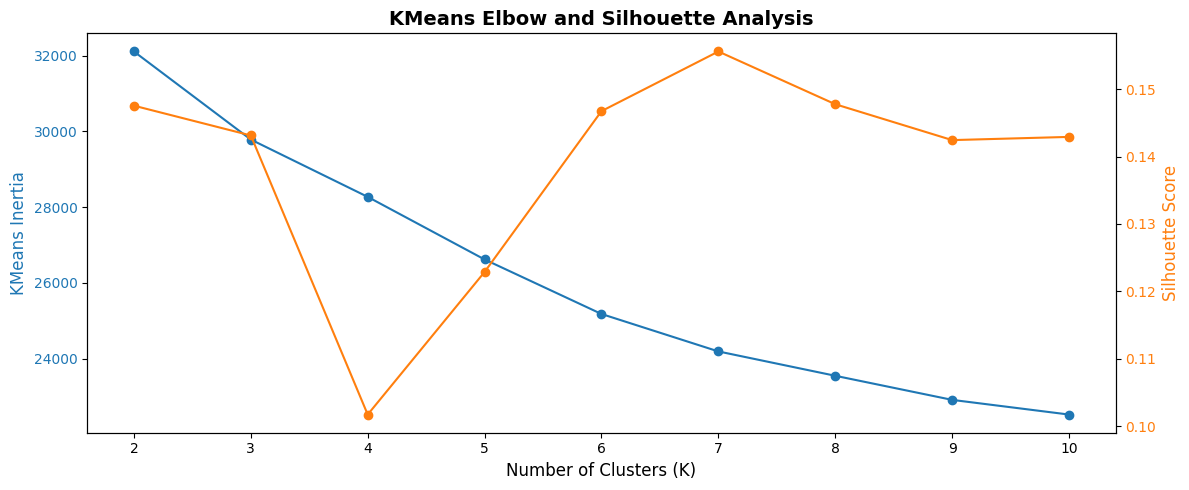

In [215]:

# Elbow & Silhouette plots for KMeans
fig, ax1 = plt.subplots(figsize=(12, 5))
color = "tab:blue"
ax1.set_xlabel("Number of Clusters (K)", fontsize=12)
ax1.set_ylabel("KMeans Inertia", color=color, fontsize=12)
ax1.plot(range(2, 11), kmeans_inertia, marker="o", color=color)
ax1.tick_params(axis="y", labelcolor=color)
ax2 = ax1.twinx()
color = "tab:orange"
ax2.set_ylabel("Silhouette Score", color=color, fontsize=12)
ax2.plot(range(2, 11), kmeans_silhouette, marker="o", color=color)
ax2.tick_params(axis="y", labelcolor=color)
plt.title("KMeans Elbow and Silhouette Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()